# Macroeconomic Sensitivity Analysis

## Objective

This notebook quantifies the magnitude of macroeconomic shocks under the Baseline, Downside and Severe scenarios developed in Notebook 06.

Rather than estimating sensitivities from historical portfolio default rates (which are unavailable), this notebook calculates the percentage shock of each macroeconomic variable relative to the baseline scenario.

These shocks are then translated into stress multipliers using expert judgement. The resulting multipliers will be applied to the base Probability of Default (PD) predictions in the next notebook.

## Inputs

• Baseline Scenario
• Downside Scenario
• Severe Scenario

## Outputs

• Scenario comparison table
• Percentage shocks
• Stress multipliers
• Visualizations


In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

In [105]:
scenario_df = pd.DataFrame({

    "Variable":[
        "GDP_Growth",
        "Unemployment_Rate",
        "Federal_Funds_Rate",
        "CPI_Rate",
        "HPI_Growth",
        "Income_Growth"
    ],

    "Baseline":[
        0.583571,
        4.210417,
        4.466667,
        0.613294,
        0.585053,
        0.377772
    ],

    "Downside":[
        -1.661950,
        9.783333,
        0.138333,
        1.201137,
        -3.741560,
        -1.567608
    ],

    "Severe":[
       -5.908646,
        11.740000,
        0.069000,
        1.016585,
        0.842160,
        -3.021443
    ]

})

scenario_df

,Variable,Baseline,Downside,Severe
0,GDP_Growth,0.583571,-1.661950,-5.908646
1,Unemployment_Rate,4.210417,9.783333,11.740000
2,Federal_Funds_Rate,4.466667,0.138333,0.069000
3,CPI_Rate,0.613294,1.201137,1.016585
4,HPI_Growth,0.585053,-3.741560,0.842160
5,Income_Growth,0.377772,-1.567608,-3.021443


In [106]:
# Variables that should use absolute percentage-point differences
pp_variables = [
    "GDP_Growth",
    "CPI_Rate",
    "HPI_Growth",
    "Income_Growth"
]

# Variables that should use relative percentage changes
pct_variables = [
    "Unemployment_Rate",
    "Federal_Funds_Rate"
]

# Initialize columns
scenario_df["Downside_Shock_%"] = np.nan
scenario_df["Severe_Shock_%"] = np.nan

# -----------------------------
# Percentage-point differences
# -----------------------------
mask = scenario_df["Variable"].isin(pp_variables)

scenario_df.loc[mask, "Downside_Shock_%"] = (
    scenario_df.loc[mask, "Downside"]
    - scenario_df.loc[mask, "Baseline"]
)

scenario_df.loc[mask, "Severe_Shock_%"] = (
    scenario_df.loc[mask, "Severe"]
    - scenario_df.loc[mask, "Baseline"]
)

# -----------------------------
# Relative percentage changes
# -----------------------------
mask = scenario_df["Variable"].isin(pct_variables)

scenario_df.loc[mask, "Downside_Shock"] = (
    (scenario_df.loc[mask, "Downside"]
     - scenario_df.loc[mask, "Baseline"])
    / scenario_df.loc[mask, "Baseline"] * 100
)

scenario_df.loc[mask, "Severe_Shock"] = (
    (scenario_df.loc[mask, "Severe"]
     - scenario_df.loc[mask, "Baseline"])
    / scenario_df.loc[mask, "Baseline"] * 100
)

scenario_df["Shock_Type"] = np.where(
    scenario_df["Variable"].isin(pp_variables),
    "Percentage Points",
    "Relative %"
)

scenario_df["Downside_Shock"] = (
    scenario_df["Downside_Shock"]
    .fillna(scenario_df["Downside_Shock_%"])
)

scenario_df["Severe_Shock"] = (
    scenario_df["Severe_Shock"]
    .fillna(scenario_df["Severe_Shock_%"])
)

scenario_df.drop(
    columns=["Downside_Shock_%", "Severe_Shock_%"],
    inplace=True
)

scenario_df.round(2)

,Variable,Baseline,Downside,Severe,Downside_Shock,Severe_Shock,Shock_Type
0,GDP_Growth,0.58,-1.66,-5.91,-2.25,-6.49,Percentage Points
1,Unemployment_Rate,4.21,9.78,11.74,132.36,178.83,Relative %
2,Federal_Funds_Rate,4.47,0.14,0.07,-96.90,-98.46,Relative %
3,CPI_Rate,0.61,1.20,1.02,0.59,0.40,Percentage Points
4,HPI_Growth,0.59,-3.74,0.84,-4.33,0.26,Percentage Points
5,Income_Growth,0.38,-1.57,-3.02,-1.95,-3.40,Percentage Points


In [107]:
economic_direction = {

    "GDP_Growth":"Economic contraction reduces borrowers' repayment capacity",

    "Unemployment_Rate":"Job losses increase probability of default",

    "Federal_Funds_Rate":"Near-zero rates signal severe economic stress",

    "CPI_Rate":"Inflation erodes disposable income and debt affordability",

    "HPI_Growth":"Falling house prices weaken collateral values and borrower equity",

    "Income_Growth":"Lower income reduces debt servicing capacity"

}

scenario_df["Economic_Effect"] = (
    scenario_df["Variable"].map(economic_direction)
)

weights = {

    "GDP_Growth":0.35,

    "Unemployment_Rate":0.30,

    "Federal_Funds_Rate":0.10,

    "CPI_Rate":0.05,

    "HPI_Growth":0.10,

    "Income_Growth":0.10

}

scenario_df["Weight"] = (
    scenario_df["Variable"].map(weights)
)


scenario_df["Downside_Stress"] = (
    abs(scenario_df["Downside_Shock"])
    *scenario_df["Weight"]
)

scenario_df["Severe_Stress"] = (
    abs(scenario_df["Severe_Shock"])
    *scenario_df["Weight"]
)

scenario_df

,Variable,Baseline,Downside,Severe,Downside_Shock,Severe_Shock,Shock_Type,Economic_Effect,Weight,Downside_Stress,Severe_Stress
0,GDP_Growth,0.583571,-1.661950,-5.908646,-2.245521,-6.492217,Percentage Points,Economic contraction reduces borrowers' repaym...,0.35,0.785932,2.272276
1,Unemployment_Rate,4.210417,9.783333,11.740000,132.360191,178.832239,Relative %,Job losses increase probability of default,0.30,39.708057,53.649672
2,Federal_Funds_Rate,4.466667,0.138333,0.069000,-96.902993,-98.455224,Relative %,Near-zero rates signal severe economic stress,0.10,9.690299,9.845522
3,CPI_Rate,0.613294,1.201137,1.016585,0.587843,0.403291,Percentage Points,Inflation erodes disposable income and debt af...,0.05,0.029392,0.020165
4,HPI_Growth,0.585053,-3.741560,0.842160,-4.326613,0.257107,Percentage Points,Falling house prices weaken collateral values ...,0.10,0.432661,0.025711
5,Income_Growth,0.377772,-1.567608,-3.021443,-1.945380,-3.399215,Percentage Points,Lower income reduces debt servicing capacity,0.10,0.194538,0.339921


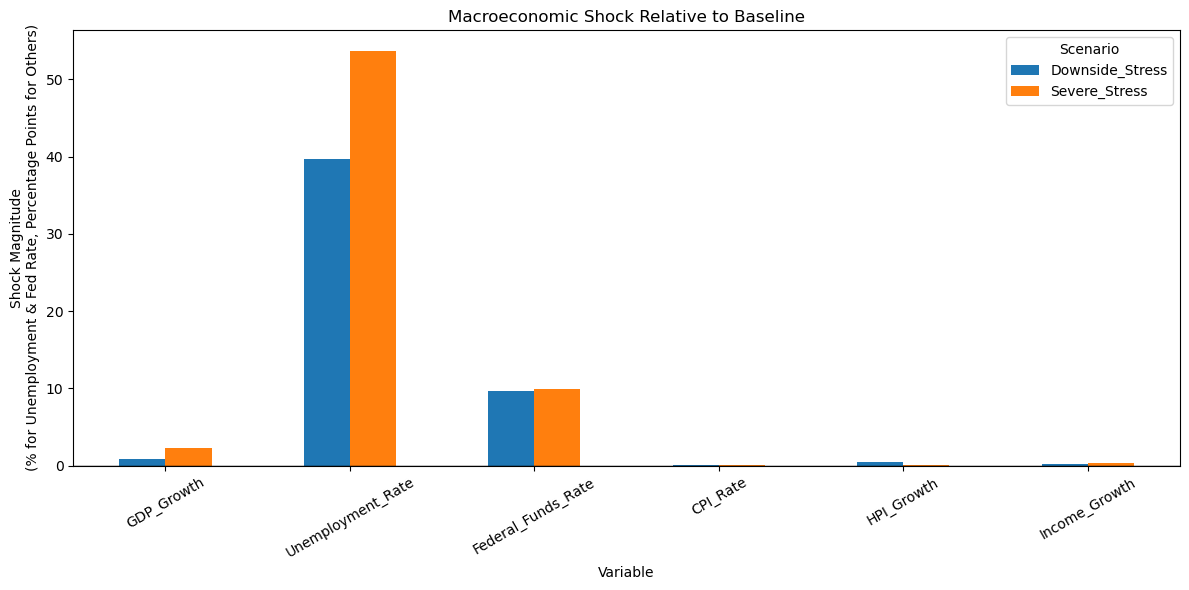

In [108]:
shock_plot = scenario_df.set_index("Variable")[[
    "Downside_Stress",
    "Severe_Stress"
]]

ax = shock_plot.plot(
    kind="bar",
    figsize=(12,6)
)

plt.axhline(0, color="black", linewidth=1)

plt.ylabel("Shock Magnitude\n(% for Unemployment & Fed Rate, Percentage Points for Others)")

plt.title("Macroeconomic Shock Relative to Baseline")

plt.xticks(rotation=30)

plt.legend(title="Scenario")

plt.tight_layout()

plt.show()

In [109]:
# Maximum historical shock for each variable
scenario_df["Max_Historical_Shock"] = scenario_df[
    ["Downside_Shock", "Severe_Shock"]
].abs().max(axis=1)

# Normalize to [0,1]
scenario_df["Downside_Normalized"] = (
    scenario_df["Downside_Shock"].abs()
    / scenario_df["Max_Historical_Shock"]
)

scenario_df["Severe_Normalized"] = (
    scenario_df["Severe_Shock"].abs()
    / scenario_df["Max_Historical_Shock"]
)

In [110]:
scenario_df["Downside_Contribution"] = (
    scenario_df["Downside_Normalized"]
    * scenario_df["Weight"]
)

scenario_df["Severe_Contribution"] = (
    scenario_df["Severe_Normalized"]
    * scenario_df["Weight"]
)

In [111]:
stress_index = pd.DataFrame({
    "Scenario": ["Moderate Stress (GFC)", "Pandemic Stress (COVID)"],
    "Stress_Index": [
        scenario_df["Downside_Contribution"].sum(),
        scenario_df["Severe_Contribution"].sum()
    ]
})

stress_index

,Scenario,Stress_Index
0,Moderate Stress (GFC),0.648752
1,Pandemic Stress (COVID),0.890245


In [112]:
k_values = [0.3, 0.5, 0.7, 1.0]

for k in k_values:
    stress_index[f"PD_Multiplier_k={k}"] = np.exp(
        k * stress_index["Stress_Index"]
    )
    
stress_index

,Scenario,Stress_Index,PD_Multiplier_k=0.3,PD_Multiplier_k=0.5,PD_Multiplier_k=0.7,PD_Multiplier_k=1.0
0,Moderate Stress (GFC),0.648752,1.214856,1.383167,1.574797,1.913152
1,Pandemic Stress (COVID),0.890245,1.306136,1.560681,1.864833,2.435726


In [113]:
scenario_df.to_csv(
    "../outputs/Macro_Sensitivity_Table.csv",
    index=False
)

stress_index.to_csv(
    "../outputs/PD_Stress_Multipliers.csv",
    index=False
)